# Homework 7

Euler's method error vs h

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

dy = lambda x, y: -2*y * np.cos(x)
true_y = lambda x: np.exp(2* np.sin(x))

def euler(dy, y0, h, end):
    x = np.arange(0, end+h, h)
    y = np.zeros_like(x)
    err = np.zeros_like(x)
    y[0] = y0
    err[0] = 0
    for i in range(1,len(x)):
        y[i] = y[i-1] + h*dy(x[i-1], y[i-1])
        err[i] = true_y(x[i]) - y[i]
    return x, y, err

hs = np.insert(np.arange(0.05, 1.05, 0.05), 0, 0.01)
xs, ys, errs = ([], [], [])
for h in hs:
    x, y, err = euler(dy, 1, h, 10*np.pi)
    xs.append(x)
    ys.append(y)
    errs.append(err)
    
err_15 = []
for x, y in zip(xs, ys):
    i = np.abs(x-15).argmin()
    err_15.append(true_y(x[i]) - y[i])

## Graphing

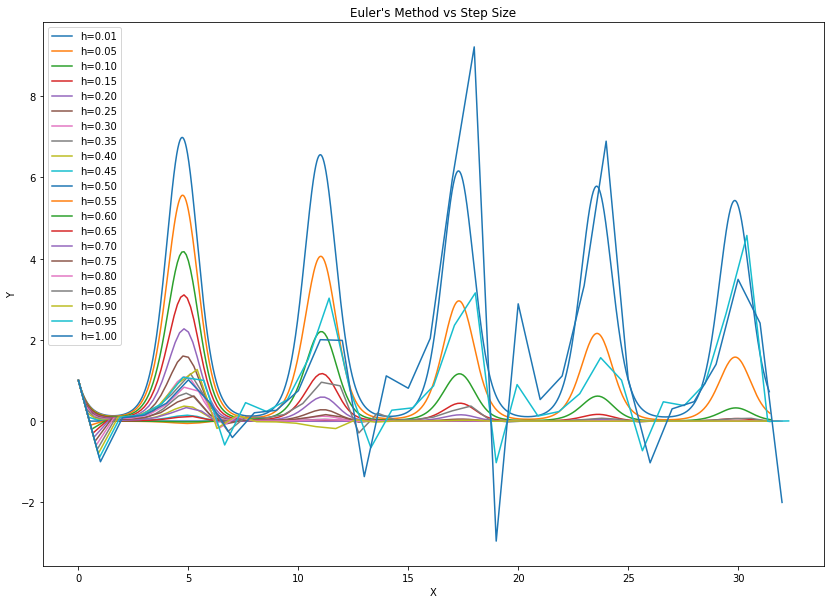

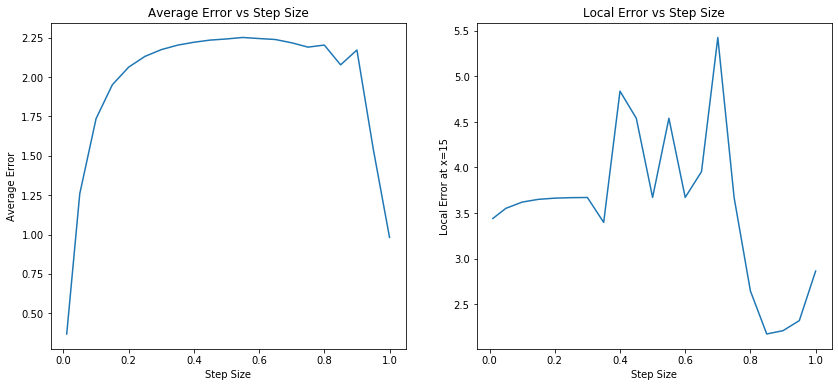

In [2]:
plt.figure(figsize=(14,10))
for x, y, h in zip(xs, ys, hs):
    plt.plot(x, y, label=f"h={h:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Euler's Method vs Step Size")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
avg_err = np.array([np.mean(err) for err in errs])
plt.plot(hs, avg_err)
plt.xlabel("Step Size")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")

plt.subplot(1,2,2)
plt.plot(hs, err_15)
plt.xlabel("Step Size")
plt.ylabel("Local Error at x=15")
plt.title("Local Error vs Step Size")
plt.show()

The smaller the step size, the farther away it gets from the real curve, until the step size gets big enough to be a large fraction of the frequency, 2 pi. Then it starts to look like a piecewise function and while it remains in the general area of the curve, it is much less accurate. The average error supports this claim with a small error for h<0.1 and relatively constant error for h>0.1. The local error is much more dependent on the position since even the h>0.5 estimates can happen to be close at this one position as is the case here at x=15.

# Addendum (HW 7s)

- Look at f(x,y) in Homework 7, can we do a Stability Analysis on -2y*cos(x)?

Yes, we can do a very similar stability analysis on this function because the added cos(x) is bounded between 0 and 1 and shouldn't impact the stability of the solution.

- How can we apply what we've done with f(x,y) = -2y? How with that x component? What's our λ?

Since cos(x) is bounded, the multivariable stability analysis simplifies to the same method as before, except this time lambda = -2*cos(x) instead of just -2.

- Find the stability condition for -2y*cos(x)

If lambda = -2\*cos(x), then z = -2h\*cos(x), and the stability condition (|1 + z| <= 1) becomes |1 - 2h\*cos(x)| <= 1.